In [1]:
%run ../bootstrap.py

[Bootstrap] cwd=/home/ikk/renal-calculi-classificaction | seed=57


In [2]:
from src.data.dataset_builder import DatasetBuilder, assign_task_labels
from src.features.feature_extractor import FeatureExtractor
from src.features.lbp import LocalBinaryPattern
from src.features.hsv import HSV_extractor
from src.pipelines.xgboost_pipeline import XGBoostExperiment
#df 
from src.analysis.umap_analysis import generate_umap
from src.utils.constants import PATCH_SIZE
import pandas as pd

In [3]:
#builder 
builder = DatasetBuilder(DATASET_PATH)
#extractor
lbp = LocalBinaryPattern()
hsv = HSV_extractor()
extractor = FeatureExtractor(hsv, lbp)

  Features shape: (397, 40)
  Distribución: {0: 192, 1: 205}


/home/ikk/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/ikk/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/ikk/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


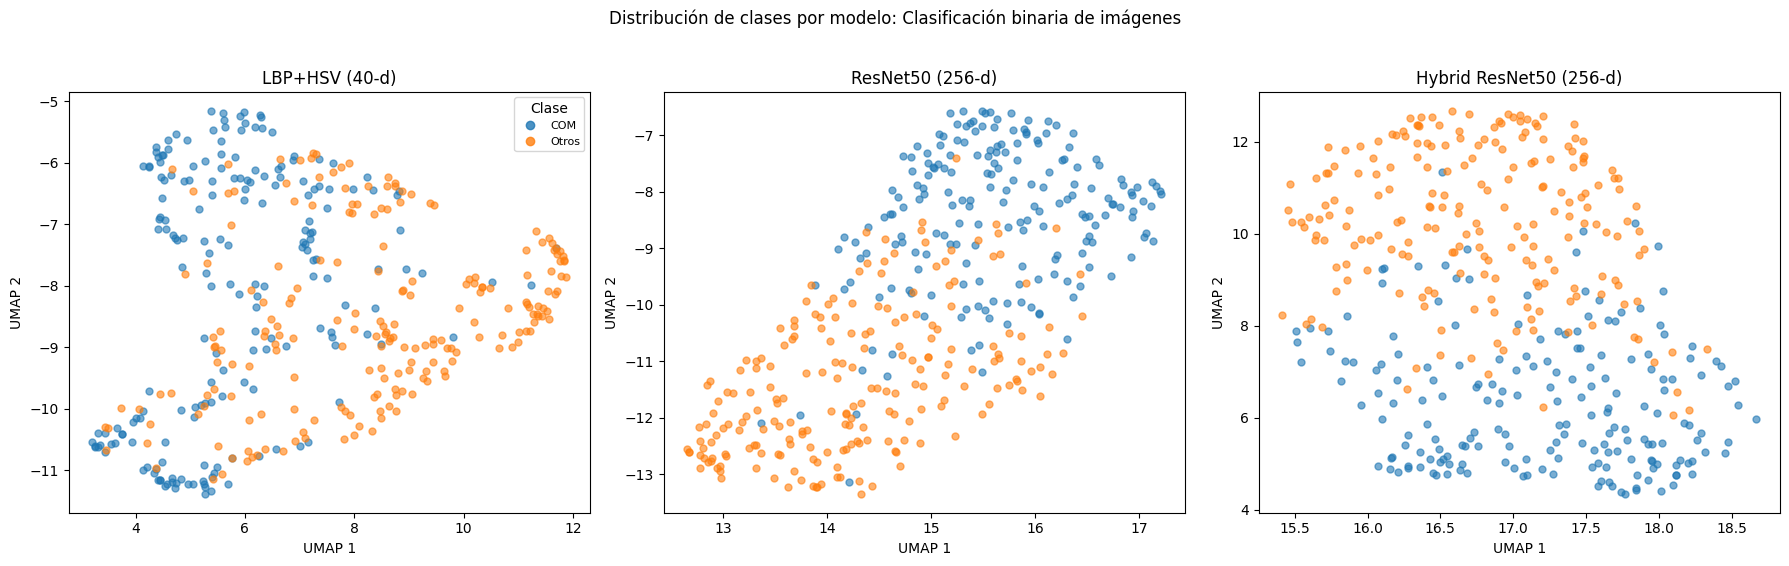

In [4]:

df_imagenes_binario = builder.build(classes=TASKS["binario"]["classes"])

generate_umap(
    df=df_imagenes_binario,
    class_names=TASKS["binario"]["class_names"],
    extractor=extractor,
    task_name="binario",
    case=Case.IMAGE  
);

  Features shape: (397, 40)
  Distribución: {0: 192, 1: 24, 2: 115, 3: 35, 4: 31}


/home/ikk/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/ikk/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/ikk/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


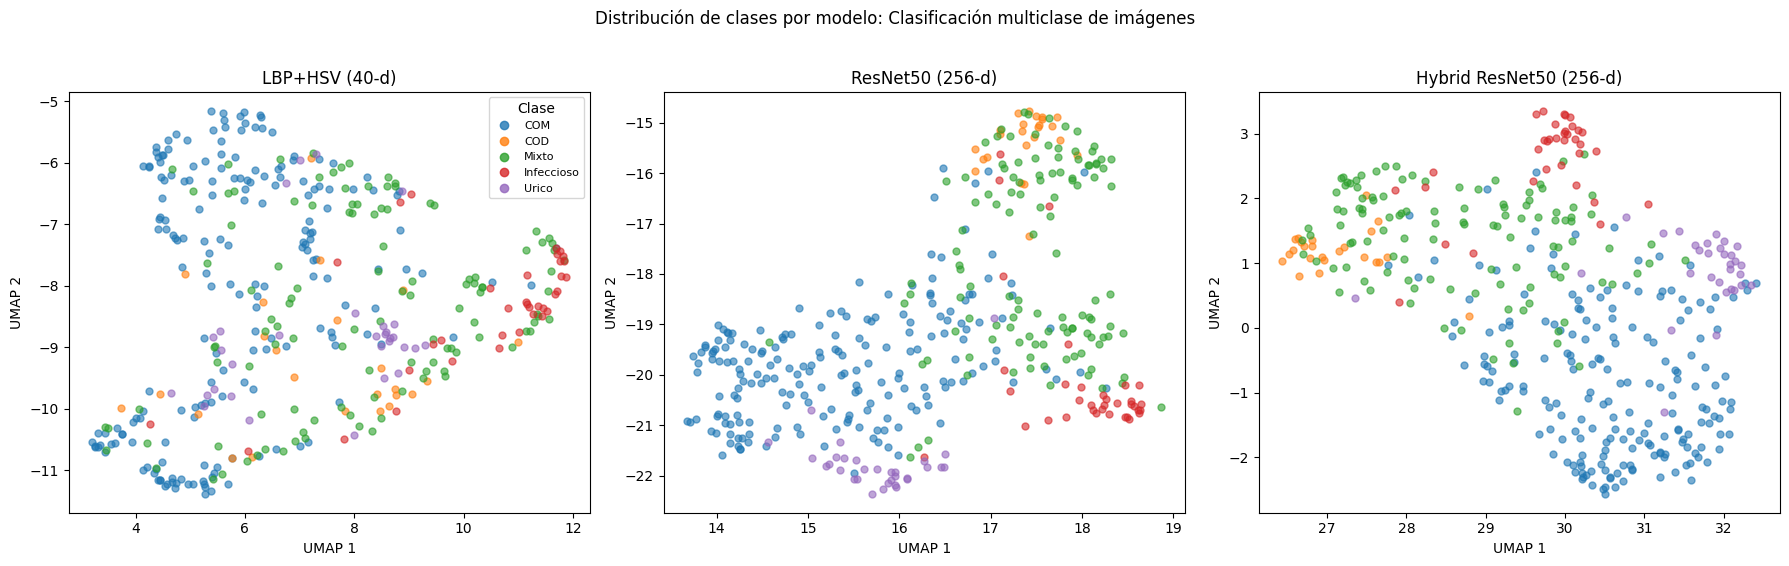

In [5]:

df_imagenes_multiclase = builder.build(classes=TASKS["multiclase"]["classes"])
generate_umap(
    df=df_imagenes_multiclase,
    class_names=TASKS["multiclase"]["class_names"],
    extractor=extractor,
    task_name="multiclase",
    case=Case.IMAGE  
);


In [9]:
# import sys
# !{sys.executable} -m pip install --target /home/ikk/.local/lib/python3.10/site-packages scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 38.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 15.3 MB/s eta 0:00:00
  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
  Using cached packaging-26.2-py3-none-any.whl (100 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 19.6 MB/s eta 0:00:0000:0100:01
  Using cached imageio-2.37.3-py3-none-any.whl (317 kB)
  Using cached networkx-3.4.2-py3-none-any.whl (1.7 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 45.8 MB/s eta 0:00:00:00:0100:01
  Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyarrow 15.0.0 requires numpy<2,>=1.16.6, but you have numpy 2.2.6 which is incompatible.
pandas 2.2.1 requires numpy<2,>=1.22.4; python_version < "3.1

PARCHES

  Features shape: (5290, 40)
  Distribución: {0: 2767, 1: 298, 2: 1372, 3: 485, 4: 368}


/home/ikk/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/ikk/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/ikk/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


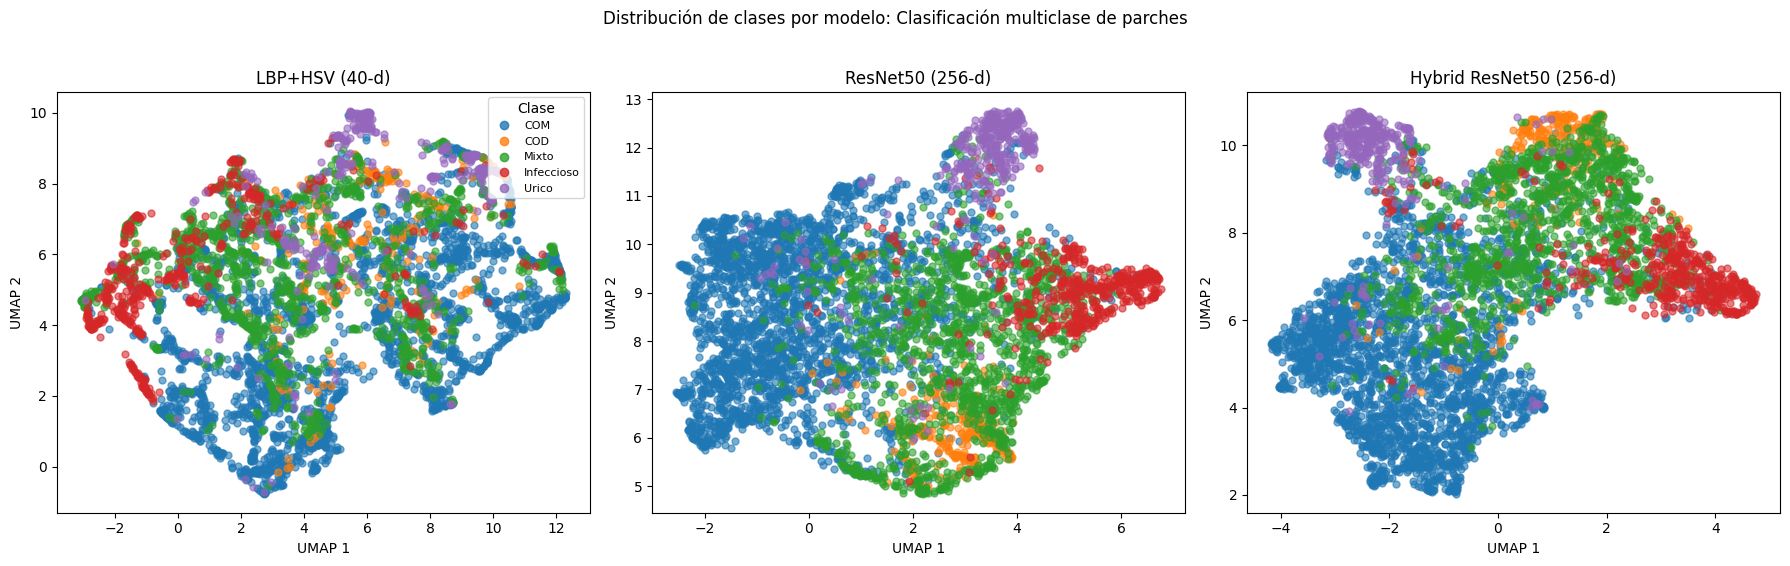

In [14]:
patches_df_full = pd.read_csv(f"experiments/patches_{PATCH_SIZE}_metadata.csv")

patches_task = assign_task_labels(patches_df_full, TASKS["multiclase"])


generate_umap(
    df=patches_task,
    class_names=TASKS["multiclase"]["class_names"],
    extractor=extractor,
    task_name="multiclase",
    case=Case.PATCH  
);

VISUALIZACIÓN DEL ESPACIO DE LAS IMÁGENES Y SUS AUMENTACIONES

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.preprocessing import StandardScaler


def plot_augmented_vs_original(
    features_orig, labels_orig,
    features_aug, labels_aug,
    class_names,
):
    """
    Proyecta originales y aumentadas en el mismo espacio UMAP.
    Las originales se dibujan como puntos sólidos; las aumentadas como cruces.
    El color indica la clase.
    """
    # Ajustar el reductor SOLO con las originales, luego transformar ambas
    scaler = StandardScaler().fit(features_orig)
    X_orig = scaler.transform(features_orig)
    X_aug = scaler.transform(features_aug)

    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED)
    emb_orig = reducer.fit_transform(X_orig)
    emb_aug = reducer.transform(X_aug)   # proyecta sobre el mismo espacio

    fig, ax = plt.subplots(figsize=(9, 7))
    cmap = plt.cm.tab10

    for cls_idx, cls_name in enumerate(class_names):
        color = cmap(cls_idx)
        # Originales: puntos sólidos
        m_orig = labels_orig == cls_idx
        ax.scatter(emb_orig[m_orig, 0], emb_orig[m_orig, 1],
                   color=color, alpha=0.7, s=40, label=f"{cls_name} (orig.)")
        # Aumentadas: cruces del mismo color
        m_aug = labels_aug == cls_idx
        ax.scatter(emb_aug[m_aug, 0], emb_aug[m_aug, 1],
                   color=color, alpha=0.4, s=30, marker="x")

    ax.legend(title="Clase", loc="best", fontsize=8)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title("Originales (•) vs aumentadas (×) en el espacio LBP+HSV")
    plt.tight_layout()
    return fig


  Features shape: (397, 40)
  Distribución: {0: 192, 1: 24, 2: 115, 3: 35, 4: 31}
  Distribución train: {'2a': 104, '1aI': 88, '3bII': 60, '4II-4I': 55, '6': 35, '8aI - 8aII': 31, '3aII': 24}
  Plan augmentación: {'2a': 0, '1aI': 0, '3bII': 1, '4II-4I': 1, '6': 2, '8aI - 8aII': 2, '3aII': 3}
  Generadas 319 muestras augmentadas
Originales: (397, 40)
Aumentadas: (319, 40)


/home/ikk/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


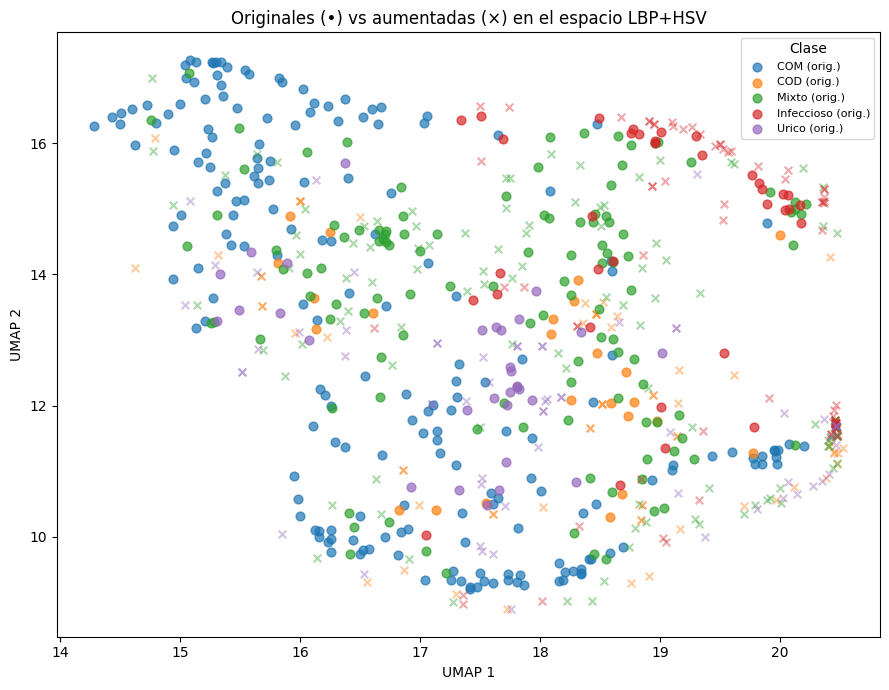

In [5]:
from src.pipelines.xgboost_pipeline import generate_augmented_features
from src.utils.constants import SEED,DATASET_PATH_XGBOOST

# Cargar el dataset de imágenes
task_name = "multiclase"
task_config = TASKS[task_name]
builder = DatasetBuilder(root_path= DATASET_PATH_XGBOOST)
df = builder.build(classes=task_config["classes"])

model = XGBoostExperiment(df, extractor, Case.IMAGE)


features_orig = model.features
labels_orig = model.labels

# 2. Generar las features aumentadas sobre TODO el dataframe

features_aug, labels_aug = generate_augmented_features(
    train_df=model.df,
    extractor=extractor,
    image_col=Case.IMAGE.image_col,
    mask_col=Case.IMAGE.mask_col,
    fold_seed=SEED,
    max_multiplier=3,        # suficiente para visualizar
    verbose=True,
)
# Submuestrear aumentadas si son demasiadas
if len(features_aug) > 500:
    idx = np.random.default_rng(SEED).choice(len(features_aug), 500, replace=False)
    features_aug = features_aug[idx]
    labels_aug = labels_aug[idx]
print(f"Originales: {features_orig.shape}")
print(f"Aumentadas: {features_aug.shape}")

# 3. Llamar a la función de visualización
fig = plot_augmented_vs_original(
    features_orig=features_orig,
    labels_orig=labels_orig,
    features_aug=features_aug,
    labels_aug=labels_aug,
    class_names=task_config["class_names"],
)

fig.savefig("experiments/plots/umap_aug_vs_orig.pdf", bbox_inches="tight")